## Import libraries

In [1]:
import os
os.chdir('../')

In [6]:
import numpy as np
import torch
import scapy.all as scapy
import logging
import matplotlib.pyplot as plt
from pathlib import Path
from src.utils.utils import load_config

In [7]:
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(message)s")

In [8]:
packets = scapy.rdpcap(str(Path("data/raw/Gmail/Gmail.pcap")))

In [9]:
packets[0][scapy.IP]


<IP  version=4 ihl=5 tos=0x0 len=1500 id=23200 flags=DF frag=0 ttl=32 proto=tcp chksum=0x652e src=1.2.179.110 dst=1.1.223.220 |<TCP  sport=http dport=3112 seq=69250436 ack=2397997938 dataofs=8 reserved=0 flags=A window=7240 chksum=0x3e24 urgptr=0 options=[('NOP', None), ('NOP', None), ('Timestamp', (379176253, 87075148))] |<Raw  load=b'HTTP/1.1 200 OK\r\nContent-Encoding: gzip\r\nExpires: Mon, 01-Jan-1990 00:00:00 GMT\r\nDate: Sun, 24 Jul 2016 03:08:11 GMT\r\nPragma: no-cache\r\nContent-Type: text/html; charset=UTF-8\r\nServer: GSE\r\nX-Content-Type-Options: nosniff\r\nCache-control: no-cache, no-store\r\nSet-Cookie: GoogleAccountsLocale_session=en\r\nSet-Cookie: GAPS=1:WmI5UGQday-9f77BE-M_4HxA_rSa8g:CjUwZC-YTiHuKuXb;Path=/accounts;Expires="Tue, 24 Jul 2018 03:08:11 GMT";HttpOnly\r\nSet-Cookie: SID=0XEmIDyeY1p7aWBR2AUa2N28jtji-0jTjn3k2FwxhiDllL4lUwFeCwlESyTdEHluvLAK18oeKebcSdTGc6GPpIBQTWegnSulAsVoTo_YIIRuSJCl-HKO6ZqQV9NuBAYif7UFU8rvLEqDgMr-HToFKNOg8ykNp_AuKawdogI0nFQUSqeTojJe8qvuZNEJ1h

In [ ]:
def process_pcaps_to_numpy(data_dir: Path, output_file: str, samples_per_class=1500):
    """
    Reads PCAPs, extracts 784 bytes per flow, anonymizes IPs, 
    and saves as a compressed NumPy archive (.npz).
    """

    all_images = []
    all_labels = []

    # Find class from folder name
    class_folders = [f for f in data_dir.iterdir() if f.is_dir()]
    label_map = {folder.name: i for i, folder in enumerate(class_folders)}

    logging.info(f"Label Mapping: {label_map}")

    for folders in class_folders:
        label = label_map[folders.name]
        count = 0
        logging.info(f"Processing Class: {folders.name} ")
        # Iterate through all pcap files in the class folder
        for pcap_file in folders.glob("*.pcap"):
            if count >= samples_per_class:
                break

            try:
                packets = scapy.rdpcap(str(pcap_file))
            except Exception as e:
                logging.error(f"Failed to read {pcap_file.name}: {e}")
                continue

            # Group packets into 5-tuple flows
            flows  = {}
            for pkt in packets:
                if not pkt.haslayer(scapy.IP):
                    continue

                ip_layer = pkt[scapy.IP]
                proto = ip_layer.proto
                sport, dport = 0, 0

                if pkt.haslayer(scapy.TCP):
                    sport, dport = pkt[scapy.TCP].sport, pkt[scapy.TCP].dport
                elif pkt.haslayer(scapy.UDP):
                    sport, dport = pkt[scapy.UDP].sport, pkt[scapy.UDP].dport

                # Flow ID is bidirectional 
                flow_id = tuple(sorted((ip_layer.src, ip_layer.dst))) + \
                        tuple(sorted((sport, dport))) + (proto,) 
                
                if flow_id not in flows:
                    flows[flow_id] = []
                flows[flow_id].append(pkt)
            
            # Convert flows to 28 * 28 images
            for flow_id, flow_pkts in flows.items():
                if count >= samples_per_class:
                    break

                # Concatenate raw bytes of all packets in the flow
                raw_bytes = b"".join([scapy.raw(p) for p in flow_pkts])

                # Truncate or Pad to 784 bytes
                flow_buffer = bytearray(raw_bytes[:784])
                if len(flow_buffer) < 784:
                    flow_buffer.extend(b'\x00' * (784 - len(flow_buffer)))

                # Anonymization (Zero out IPs in IPv4 header: bytes 12-19)
                for i in range(12, 20):
                    flow_buffer[i] = 0x00

                # Normalize and reshape to (1, 28, 28)
                img = np.frombuffer(flow_buffer, dtype=np.uint8).astype(np.float32) / 255.0
                img = img.reshape(1, 28, 28)

                all_images.append(img)
                all_labels.append(label)
                count += 1

    # Convert to final NumPy arrays
    final_x = np.array(all_images)
    final_y = np.array(all_labels)

    np.savez_compressed(output_file,
                        x=final_x, 
                        y=final_y,
                        labels=list(label_map.keys()))
    
    logging.info(f"Successfully saved {final_x.shape[0]} samples.")
    logging.info(f"Final Data Shape: {final_x.shape} (N, C, H, W)")




In [11]:
config = load_config()

RAW_DATA_PATH = Path(config['paths']['raw_data_dir'])
OUTPUT_FILE = Path(config['paths']['output_data_file'])

In [ ]:
process_pcaps_to_numpy(RAW_DATA_PATH, OUTPUT_FILE, samples_per_class=1500)

2026-01-03 18:14:10,348 - INFO - Label Mapping: {'BitTorrent': 0, 'Cridex': 1, 'Gmail': 2, 'Skype': 3, 'Tinba': 4, 'Zeus': 5}
2026-01-03 18:14:10,349 - INFO - Processing Class: BitTorrent 
2026-01-03 18:14:15,392 - INFO - Processing Class: Cridex 
2026-01-03 18:16:15,169 - INFO - Processing Class: Gmail 
2026-01-03 18:16:21,448 - INFO - Processing Class: Skype 
2026-01-03 18:16:24,599 - INFO - Processing Class: Tinba 
2026-01-03 18:16:34,178 - INFO - Processing Class: Zeus 
2026-01-03 18:17:09,758 - INFO - Successfully saved 9000 samples.
2026-01-03 18:17:09,759 - INFO - Final Data Shape: (9000, 1, 28, 28) (N, C, H, W)


In [6]:
data = np.load(OUTPUT_FILE)

In [15]:
X = data["x"]
y = data["y"]

In [38]:
CRIDEX_IDX = 1

In [39]:
sample_idx = np.where(y == CRIDEX_IDX)[0]
sample_img = X[sample_idx[300]]

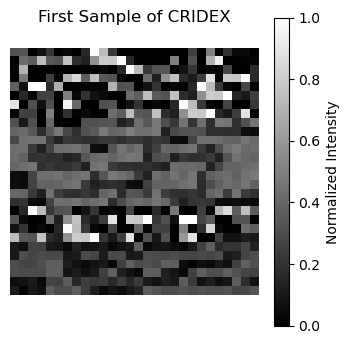

In [40]:
plt.figure(figsize=(4, 4))
plt.imshow(sample_img.squeeze(), cmap='gray')
plt.title(f"First Sample of CRIDEX\n")
plt.colorbar(label='Normalized Intensity')
plt.axis('off')
plt.show()
